# Bài 8: Bài toán phân cụm

In [1]:
import numpy as np
import random, os
from IPython import display

import matplotlib.pyplot as plt          # vẽ hình
from collections import Counter

import pandas as pd
from sklearn.datasets import make_blobs  # tạo tập điểm phân bố Gaussian
from sklearn.cluster import KMeans       # thuật toán phân cụm k-means

import warnings
warnings.filterwarnings("ignore")

# cố định random-state để phục hồi lại kết quả thí nghiệm
random_state = 42
random.seed(random_state)
os.environ['PYTHONHASHSEED'] = str(random_state)
np.random.seed(random_state)

## Bài 3. Bài tập áp dụng

Áp dụng thuật toán k-means cho tập dữ liệu sau:
+ Tập điểm dữ liệu $X_3$ gồm 300 điểm 2 chiều chỉ có 1 lớp dữ liệu với mean $m_1=\left(0, 0\right)$ và $S_1 = I$.

### 1. Tạo và hiển thị dữ liệu

In [2]:
# Sinh tập hợp điểm theo phân phối Gaussian
X3, y3 = make_blobs(n_samples    = 300,                         # số lượng điểm
                    centers      = [[0,0]], # vị trí tâm
                    cluster_std  = [1],          # độ phân tán
                    random_state = random_state,                # seed ngẫu nhiên
                   )

In [3]:
# lưu trữ trong pandas
df_points = pd.DataFrame(X3, columns=["x", "y"])
df_points["label"] = y3

# tính số lớp, tần số xuất hiện mỗi lớp
n_classes = len(np.unique(df_points["label"])) # tính số lớp dữ liệu
labels, cnts = np.unique(df_points["label"], return_counts=True)
n_cnts = dict(zip(labels, cnts))
print(f'+ labels={labels}\n+ cnts={cnts}\n+ n_cnts={n_cnts}')

# hiển thị dữ liệu
display.display(df_points)

+ labels=[0]
+ cnts=[300]
+ n_cnts={np.int64(0): np.int64(300)}


,x,y,label
0,-1.191303,0.656554,0
1,-0.544383,0.110923,0
2,0.120296,0.514439,0
3,-0.981509,0.462103,0
4,0.058209,-1.142970,0
...,...,...,...
295,-0.715304,0.679598,0
296,-0.846794,-1.514847,0
297,0.443819,0.774634,0
298,-0.471038,0.232050,0


Center 0: [-0.01078431 -0.01625424]


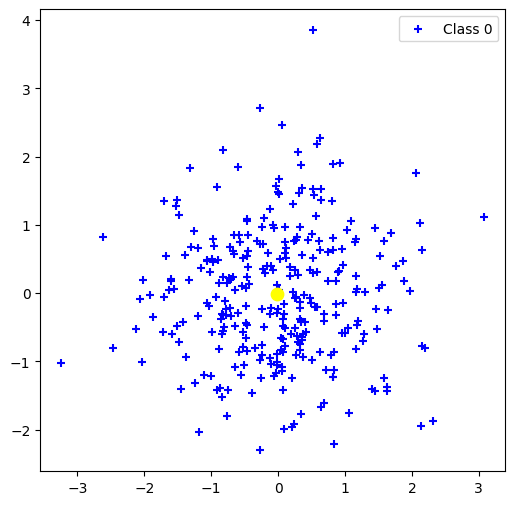

In [4]:
# màu của từng lớp
colors = {0:'b', 1:'g',2:'r',3:'c', 4:'m', 5:'y', 6:'k', 7:'w'} 

# vẽ tập dữ liệu điểm
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(n_classes):
    # tính toán điểm trung tâm từng lớp
    p_center = np.mean(X3[y3==i], axis = 0) 
    print(f'Center {i}: {p_center}')
    # vẽ tập điểm
    plt.scatter(X3[y3==i, 0], X3[y3==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(p_center[0], p_center[1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 2. Áp dụng thuật toán phân cụm

####  2.1. Số cụm m = 1 ngẫu nhiên

In [7]:
m = 1 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X3); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels  = sum(y3 == y_pred) # tính độ chính xác

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

Centers:
[[-0.01078431 -0.01625424]]
Inertia: 566.1441177353726
Correct Labels: 300 / 300
Accuracy score: 1.00


Predict: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
Center 0: [-0.01078431 -0.01625424]


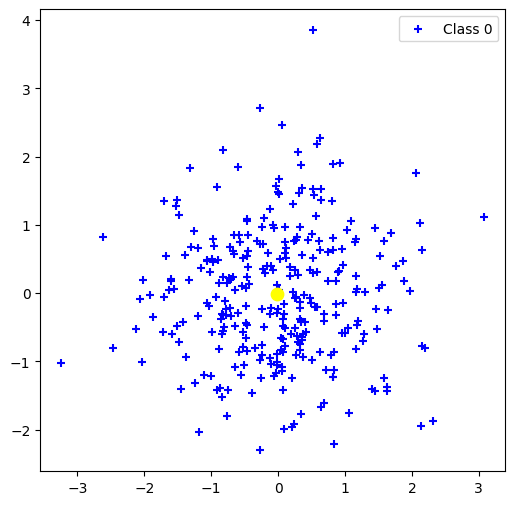

In [8]:
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X3[y_pred==i, 0], X3[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

####  2.2. Số cụm m = 2 ngẫu nhiên

Centers:
[[ 0.71348745  0.22832208]
 [-0.76461817 -0.27081326]]
Inertia: 383.6555475521036
Correct Labels: 154 / 300
Accuracy score: 0.51

Predict: [1 1 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 0 1 0] ...
Center 0: [0.71348745 0.22832208]
Center 1: [-0.76461817 -0.27081326]


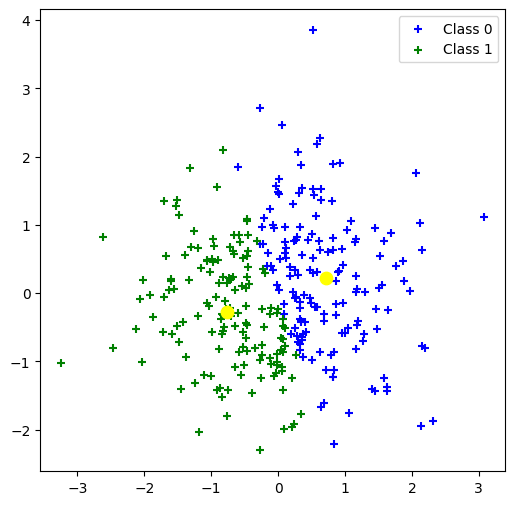

In [9]:
m = 2 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X3); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y3 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X3[y_pred==i, 0], X3[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.3. Số cụm m = 3 ngẫu nhiên

Centers:
[[ 0.57599483 -0.74860702]
 [ 0.40561923  0.98498057]
 [-1.07192329 -0.18144193]]
Inertia: 247.45650685029239
Correct Labels: 108 / 300
Accuracy score: 0.36

Predict: [2 2 1 2 0 0 0 1 2 2 1 2 0 0 0 0 1 1 2 1] ...
Center 0: [ 0.57599483 -0.74860702]
Center 1: [0.40561923 0.98498057]
Center 2: [-1.07192329 -0.18144193]


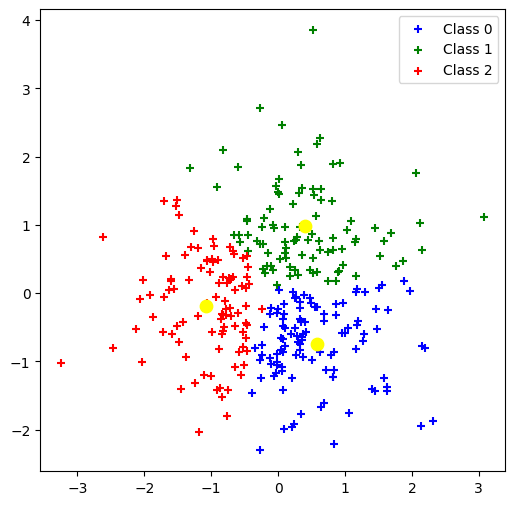

In [11]:
m = 3 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X3); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y3 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X3[y_pred==i, 0], X3[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.4. Số cụm m = 1 xác định trước

Centers:
[[-0.01078431 -0.01625424]]
Inertia: 566.1441177353726
Correct Labels: 300 / 300
Accuracy score: 1.00

Predict: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
Center 0: [-0.01078431 -0.01625424]


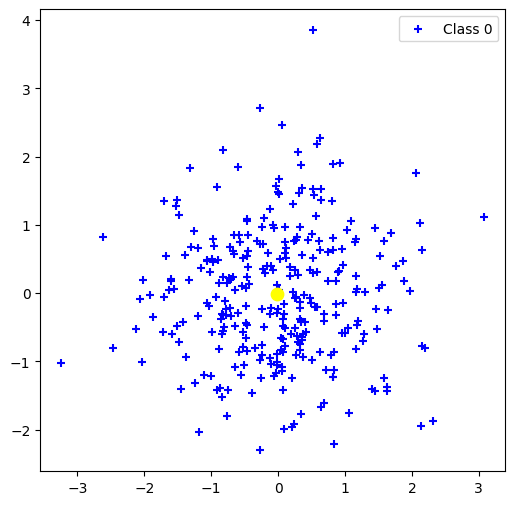

In [13]:
m = 1 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, 
                init = np.array([[-2,-2]]),
                n_init = 1, # chỉ chạy 1 lần k_means
                random_state=random_state) # thuật toán kmean
kmeans.fit(X3); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y3 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X3[y_pred==i, 0], X3[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

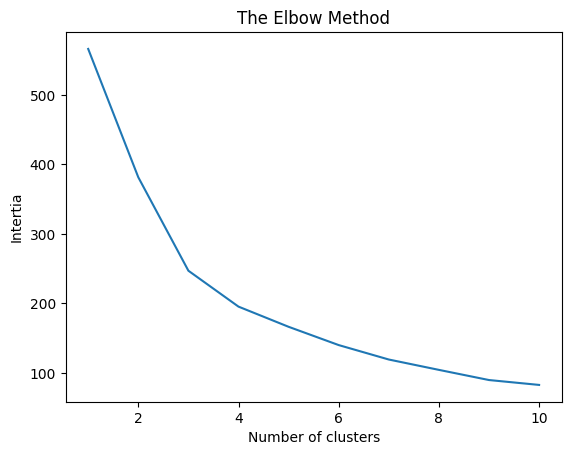

In [14]:
list_intertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,      # số cluster
                    init = 'k-means++',  # khởi tạo ngẫu nhiên dùng k-means++
                    max_iter = 300,      # số lần lặp trong thuật toán
                    n_init = 10,         # số lần chạy lại k-means và lấy tốt nhất
                    random_state = random_state,
                   )
    kmeans.fit(X3)
    list_intertia.append(kmeans.inertia_)
plt.plot(range(1, 11), list_intertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

# Kết thúc
